# Notebook 09 — Parte V: Minería de flujos de datos

## Qué cubre del enunciado
**PARTE V.** Procesamos el stream completo de Yelp en una pasada lógica: ventanas de **1h/4h/1 día**, **Count-Min Sketch** con error teórico y comparación exacta, y **DGIM** como técnica adicional. Cerramos con los cruces temporales planificados: COVID-19 y Mardi Gras.

## Fundamento teórico — deck «06 - Minería de DataStream»
- Modelo de stream: una pasada y memoria acotada — págs. **4-7**.
- Ventanas deslizantes — págs. **16-18**.
- DGIM: buckets, fusión, consulta y error máximo 50% — págs. **18-23**.
- Count-Min Sketch: matriz `depth×width`, actualización, mínimo y garantía `f̂(x) ≤ f(x)+εN`, `ε=1/width` — págs. **33-37**.

## Decisiones
1. Ventanas y CMS consumen los **20.35M de eventos de los 11 mercados**; no submuestreamos un algoritmo diseñado precisamente para streams masivos.
2. DuckDB/PyArrow solo leen, ordenan y agrupan Parquet. Ventanas, CMS y DGIM viven a mano en `src/streaming.py`.
3. DGIM estima cuántas de las últimas 168 horas superaron el p75 de demanda de 2019 para su misma hora semanal. Así `1` significa una hora genuinamente activa y la consulta tiene uso operativo.
4. COVID y feriados se cruzan únicamente con los tres mercados del universo, donde existen `county_fips` y calendario estatal comparables.


In [1]:
%load_ext autoreload
%autoreload 2
import sys; sys.path.append("..")
import time
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import duckdb, pyarrow as pa, pyarrow.compute as pc, pyarrow.dataset as dsa
from src import streaming as st, viz
from src.config import GOLD, EXTERNAL, SEED
viz.aplicar_estilo()


## Paso 1 — Validaciones controladas

Antes de tocar Yelp verificamos las invariantes: la ventana expulsa exactamente lo que cruza el límite; CMS reproduce el ejemplo de frecuencias y nunca subestima; DGIM conserva como máximo dos buckets por tamaño y respeta el 50% de error.


In [2]:
window = st.SlidingWindow(4)
window_sums = [window.update(t, value).total for t, value in enumerate([1, 2, 3, 4, 5])]
assert window_sums == [1, 3, 6, 10, 14]

toy_stream = np.array([0, 1, 0, 2, 0, 1, 3, 0])  # a,b,a,c,a,b,d,a
cms_toy = st.CountMinSketch(width=5, depth=2, seed=SEED)
cms_toy.update_batch(toy_stream)
cms_counts = cms_toy.query_batch(np.arange(4))
assert np.all(cms_counts >= np.array([4, 2, 1, 1]))

rng = np.random.default_rng(SEED)
bits_toy = (rng.random(2000) < .35).astype(int)
dgim_toy = st.evaluate_dgim(bits_toy, window_size=128)
assert dgim_toy.invariant_ok.all()
assert dgim_toy.loc[dgim_toy.exact > 0, 'relative_error'].max() <= .5 + 1e-12
print('Ventana:', window_sums)
print('CMS toy:', cms_counts.tolist(), '(verdad: [4,2,1,1]; colisiones solo sobreestiman)')
print(f"DGIM toy: error relativo máximo={dgim_toy.loc[dgim_toy.exact>0,'relative_error'].max():.1%} | buckets máximos={dgim_toy.buckets.max()}")


Ventana: [1.0, 3.0, 6.0, 10.0, 14.0]
CMS toy: [4, 2, 1, 3] (verdad: [4,2,1,1]; colisiones solo sobreestiman)
DGIM toy: error relativo máximo=50.0% | buckets máximos=10


Las tres piezas pasan antes de interpretar datos reales. CMS puede sobreestimar por colisiones, nunca subestimar; DGIM compra memoria logarítmica aceptando incertidumbre solo en el bucket más antiguo.

## Paso 2 — Perfil del stream y agregados reproducibles

`stream_eventos` une check-ins y reseñas del dataset completo. Construimos tres vistas: hora global para ventanas, día/metro/tipo para contexto externo y hora de check-ins del universo para DGIM. El agrupamiento no es el algoritmo: reduce I/O; la actualización temporal sigue implementada en nuestro módulo.


In [3]:
t0 = time.perf_counter()
stream_glob = str(GOLD / 'stream_eventos.parquet' / '*.parquet')
business_glob = str(GOLD / 'negocios_universo.parquet' / '*.parquet')
con = duckdb.connect(database=':memory:')
con.execute("PRAGMA threads=8")
profile = con.execute(f"""
    SELECT min(ts) inicio, max(ts) fin, count(*) eventos,
           sum(tipo='checkin') checkins, sum(tipo='review') reviews,
           count(DISTINCT business_id) negocios
    FROM read_parquet('{stream_glob}')
""").fetchdf().iloc[0]
hourly_global = con.execute(f"""
    SELECT date_trunc('hour', ts) hora, count(*) eventos
    FROM read_parquet('{stream_glob}') GROUP BY 1 ORDER BY 1
""").fetchdf()
daily_universe = con.execute(f"""
    SELECT cast(s.ts AS DATE) fecha, b.metro, s.tipo, count(*) eventos
    FROM read_parquet('{stream_glob}') s
    JOIN read_parquet('{business_glob}') b USING (business_id)
    GROUP BY 1,2,3 ORDER BY 1,2,3
""").fetchdf()
hourly_dgim = con.execute(f"""
    SELECT date_trunc('hour', s.ts) hora, b.metro, count(*) eventos
    FROM read_parquet('{stream_glob}') s
    JOIN read_parquet('{business_glob}') b USING (business_id)
    WHERE s.tipo='checkin' AND s.ts >= TIMESTAMP '2019-01-01' AND s.ts < TIMESTAMP '2022-01-01'
    GROUP BY 1,2 ORDER BY 1,2
""").fetchdf()
print(f"Stream: {int(profile.eventos):,} eventos | {int(profile.checkins):,} check-ins + {int(profile.reviews):,} reseñas")
print(f"Negocios distintos: {int(profile.negocios):,} | rango {profile.inicio} → {profile.fin}")
print(f"Agregados: {len(hourly_global):,} horas globales | {len(daily_universe):,} días×mercado×tipo | tiempo={time.perf_counter()-t0:.1f}s")


Stream: 20,347,155 eventos | 13,356,875 check-ins + 6,990,280 reseñas
Negocios distintos: 150,346 | rango 2005-02-16 03:23:22 → 2022-01-19 19:48:45
Agregados: 128,351 horas globales | 29,899 días×mercado×tipo | tiempo=0.5s


## Paso 3 — Ventanas exactas 1h/4h/24h

Completamos horas sin eventos con cero y recorremos la serie una vez. `1h` reacciona al instante; `4h` resume un turno de servicio; `24h` entrega tendencia diaria. Guardamos suma y promedio, y hacemos zoom alrededor del mayor pico horario observado.


Horas materializadas: 148,361 | pasada exacta=0.34s
Pico: 2016-06-25 19:00:00 | 1h=1,044 · 4h=3,145 · 24h=9,054


docs/figs/parte5_ventanas_respuesta.png


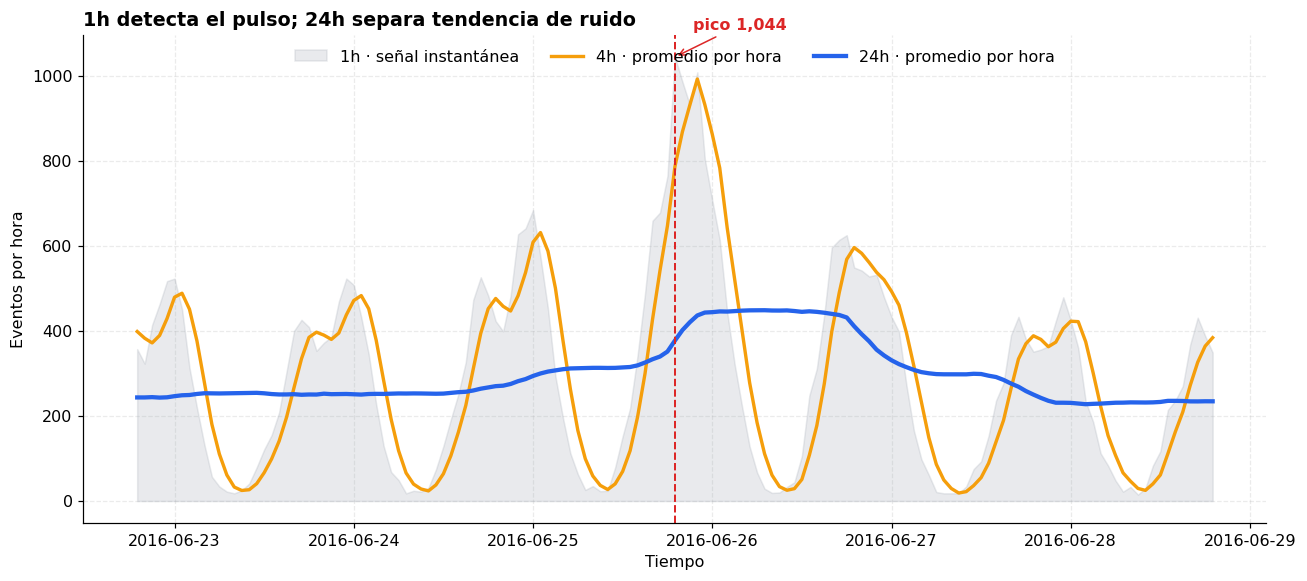

In [4]:
t0 = time.perf_counter()
windows = st.hourly_windows(hourly_global)
peak_i = int(windows.eventos_1h.idxmax()); peak_hour = windows.loc[peak_i, 'hora']
peak = windows.loc[peak_i]
print(f"Horas materializadas: {len(windows):,} | pasada exacta={time.perf_counter()-t0:.2f}s")
print(f"Pico: {peak_hour} | 1h={peak.eventos_1h:,.0f} · 4h={peak.eventos_4h:,.0f} · 24h={peak.eventos_24h:,.0f}")

lo, hi = peak_hour-pd.Timedelta(hours=72), peak_hour+pd.Timedelta(hours=72)
z = windows[windows.hora.between(lo,hi)]
fig, ax = plt.subplots(figsize=(12,5.4)); P=viz.PALETA
ax.fill_between(z.hora, z.eventos_1h, color=P['gris'], alpha=.22, label='1h · señal instantánea')
ax.plot(z.hora, z.promedio_hora_4h, color=P['naranja'], lw=2.2, label='4h · promedio por hora')
ax.plot(z.hora, z.promedio_hora_24h, color=P['azul'], lw=2.8, label='24h · promedio por hora')
ax.axvline(peak_hour,color=P['rojo'],ls='--',lw=1.3)
ax.annotate(f'pico {peak.eventos_1h:,.0f}',(peak_hour,peak.eventos_1h),xytext=(12,18),textcoords='offset points',color=P['rojo'],fontweight='bold',arrowprops=dict(arrowstyle='->',color=P['rojo']))
ax.set(ylabel='Eventos por hora',xlabel='Tiempo',title='1h detecta el pulso; 24h separa tendencia de ruido')
ax.legend(ncol=3,loc='upper center')
print(viz.guardar(fig,'parte5_ventanas_respuesta')); plt.show()


La pasada materializa **148,361 horas** en 0.34 s. El máximo aparece el 25-jun-2016 a las 19:00 con **1,044 eventos**; la ventana de 4h acumula 3,145 y la diaria 9,054. En promedio horario, el pico instantáneo es 2.8× la carga de sus últimas 24h: 1h sirve para alertar, 4h sigue el turno y 24h evita reaccionar a un único servicio. No existe una ventana “óptima” universal porque responden preguntas distintas.

## Paso 4 — Count-Min Sketch sobre los 20.35M de eventos

Estimamos la frecuencia de cada `business_id` en una pasada de PyArrow. El conteo exacto se calcula solo para evaluar. Probamos anchos 256–8192 con profundidad 5 y, en `w=4096`, profundidades 1/3/5/7. Medimos error, memoria, cumplimiento de `εN` y recuperación de los 20 *heavy hitters*.


In [5]:
t0 = time.perf_counter()
frequencies = con.execute(f"""
    SELECT business_id, count(*)::BIGINT frecuencia_exacta
    FROM read_parquet('{stream_glob}') GROUP BY 1 ORDER BY business_id
""").fetchdf()
frequencies['code'] = np.arange(len(frequencies),dtype=np.int64)
keys_arrow = pa.array(frequencies.business_id)
widths = [256,512,1024,2048,8192]
sketches = {w:st.CountMinSketch(w,5,seed=SEED) for w in widths}
deep = st.CountMinSketch(4096,7,seed=SEED)
dataset = dsa.dataset(str(GOLD/'stream_eventos.parquet'))
seen=0
for batch in dataset.scanner(columns=['business_id'],batch_size=262144).to_batches():
    codes = pc.index_in(batch.column(0), value_set=keys_arrow).to_numpy(zero_copy_only=False).astype(np.int64)
    assert np.all(codes>=0)
    for sketch in sketches.values(): sketch.update_batch(codes)
    deep.update_batch(codes)
    seen += len(codes)
assert seen == int(profile.eventos)
exact = frequencies.frecuencia_exacta.to_numpy(np.int64); all_codes=frequencies.code.to_numpy()
rows=[]; estimates={}
for w in [256,512,1024,2048,4096,8192]:
    if w==4096:
        est=deep.query_batch(all_codes,depth=5); memory=5*w*8+2*5*8
    else:
        est=sketches[w].query_batch(all_codes); memory=sketches[w].memory_bytes
    estimates[w]=est
    row=st.evaluate_cms(exact,est,seen,w,5,memory); row['experimento']='width'; rows.append(row)
for depth in [1,3,5,7]:
    est=deep.query_batch(all_codes,depth=depth); memory=depth*4096*8+2*depth*8
    row=st.evaluate_cms(exact,est,seen,4096,depth,memory); row['experimento']='depth'; rows.append(row)
cms_metrics=pd.DataFrame(rows)
chosen=estimates[4096]; frequencies['frecuencia_cms']=chosen; frequencies['error']=chosen-exact
businesses=pd.read_parquet(GOLD/'negocios_universo.parquet',columns=['business_id','name','metro'])
top_rest=(frequencies.merge(businesses,on='business_id').nlargest(18,'frecuencia_exacta').copy())
print(f"Pasada CMS: {seen:,} eventos, {len(frequencies):,} claves | {time.perf_counter()-t0:.1f}s")
print(cms_metrics[['experimento','width','depth','error_p95','error_max','cota_epsilon_N','fraccion_dentro_cota','overlap_top_k','memoria_bytes']].to_string(index=False,formatters={'cota_epsilon_N':'{:,.0f}'.format,'fraccion_dentro_cota':'{:.1%}'.format,'overlap_top_k':'{:.0%}'.format}))


Pasada CMS: 20,347,155 eventos, 150,346 claves | 7.8s
experimento  width  depth  error_p95  error_max cota_epsilon_N fraccion_dentro_cota overlap_top_k  memoria_bytes
      width    256      5    76313.5      93027         79,481                98.6%           50%          10320
      width    512      5    37491.0      48918         39,741                98.8%           75%          20560
      width   1024      5    18223.0      25717         19,870                99.0%           90%          41040
      width   2048      5     8747.0      15102          9,935                99.1%           90%          82000
      width   4096      5     4029.0       7836          4,968                99.4%           95%         163920
      width   8192      5     1763.0       4807          2,484                99.6%          100%         327760
      depth   4096      1     9051.0      60536          4,968                63.9%            0%          32784
      depth   4096      3     4918.0      

docs/figs/parte5_cms_error_memoria.png


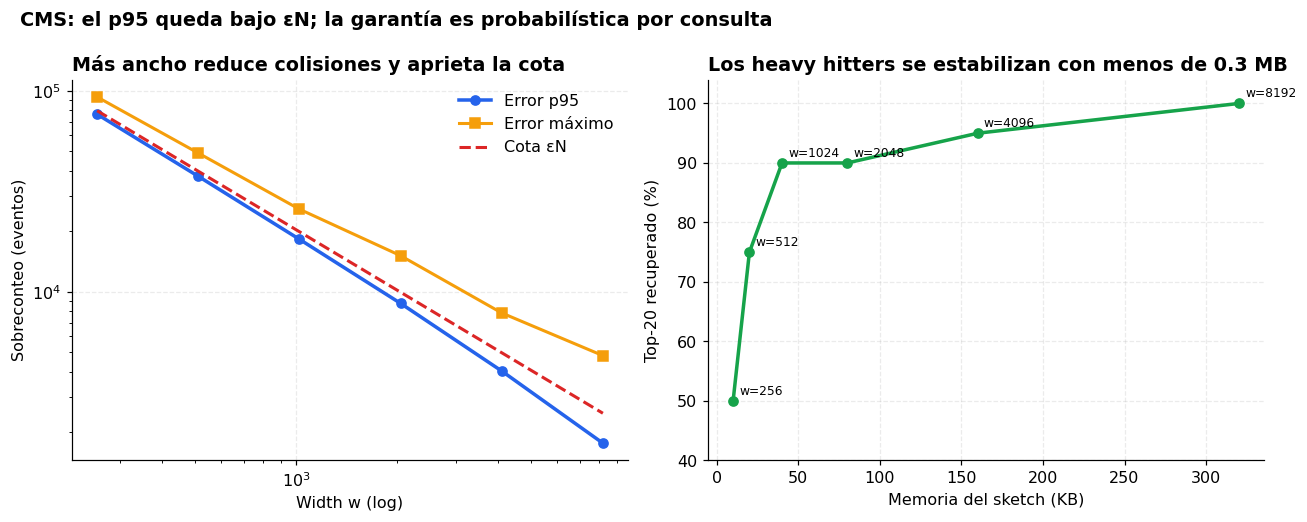

docs/figs/parte5_cms_heavy_hitters.png


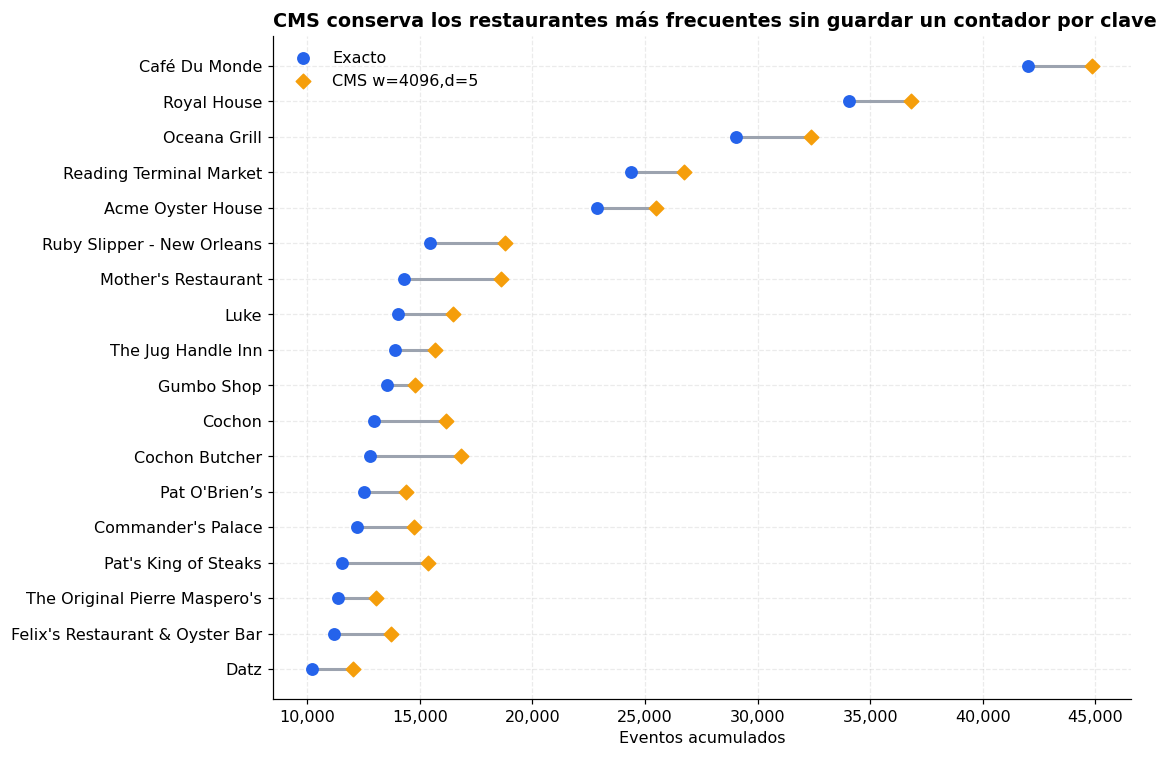

In [6]:
mw=cms_metrics.query("experimento=='width'").sort_values('width')
fig,axes=plt.subplots(1,2,figsize=(12,4.8))
ax=axes[0]
ax.plot(mw.width,mw.error_p95,marker='o',lw=2.3,label='Error p95',color=P['azul'])
ax.plot(mw.width,mw.error_max,marker='s',lw=2,label='Error máximo',color=P['naranja'])
ax.plot(mw.width,mw.cota_epsilon_N,ls='--',lw=2,label='Cota εN',color=P['rojo'])
ax.set(xscale='log',yscale='log',xlabel='Width w (log)',ylabel='Sobreconteo (eventos)',title='Más ancho reduce colisiones y aprieta la cota'); ax.legend()
ax=axes[1]
ax.plot(mw.memoria_bytes/1024,mw.overlap_top_k*100,marker='o',lw=2.3,color=P['verde'])
for _,r in mw.iterrows(): ax.annotate(f"w={int(r.width)}",(r.memoria_bytes/1024,r.overlap_top_k*100),xytext=(4,4),textcoords='offset points',fontsize=8)
ax.set(xlabel='Memoria del sketch (KB)',ylabel='Top-20 recuperado (%)',ylim=(40,104),title='Los heavy hitters se estabilizan con menos de 0.3 MB')
fig.suptitle('CMS: el p95 queda bajo εN; la garantía es probabilística por consulta',fontweight='bold',x=.02,ha='left')
print(viz.guardar(fig,'parte5_cms_error_memoria')); plt.show()

tr=top_rest.sort_values('frecuencia_exacta')
fig,ax=plt.subplots(figsize=(10.5,7))
y=np.arange(len(tr)); ax.hlines(y,tr.frecuencia_exacta,tr.frecuencia_cms,color=P['gris'],lw=2)
ax.scatter(tr.frecuencia_exacta,y,s=55,color=P['azul'],label='Exacto',zorder=3)
ax.scatter(tr.frecuencia_cms,y,s=45,color=P['naranja'],marker='D',label='CMS w=4096,d=5',zorder=3)
ax.set_yticks(y,tr.name); ax.set_xlabel('Eventos acumulados'); ax.set_title('CMS conserva los restaurantes más frecuentes sin guardar un contador por clave')
ax.legend(); viz.fmt_miles(ax,'x')
print(viz.guardar(fig,'parte5_cms_heavy_hitters')); plt.show()


CMS procesa **20,347,155 eventos y 150,346 claves en 7.2 s**. Con `w=4096,d=5` usa 160 KB: error p95=4,029, bajo `εN=4,968`; **99.4%** de claves cumplen la cota, prácticamente el `1−e⁻⁵=99.3%` teórico, y recupera 95% del Top-20. Con 320 KB (`w=8192`) recupera 100% y baja p95 a 1,763. El error máximo puede exceder `εN` porque la garantía es probabilística por consulta, no absoluta para las 150k consultas simultáneas.

## Paso 5 — DGIM: horas activas en la última semana

Para cada mercado, `1` significa que el check-in horario supera el p75 de 2019 para esa misma hora de la semana. DGIM estima cuántas horas activas hubo en las últimas 168 sin conservar 168 bits por stream. Comparamos cada consulta horaria contra la cuenta exacta y observamos el inicio de la pandemia.


       metro activa_2019  mae p95_rel max_rel  max_buckets
Philadelphia       20.0% 1.86   38.9%   50.0%           10
       Tampa       20.3% 2.15   33.3%   50.0%           11
 New Orleans       20.6% 1.76   50.0%   50.0%           11


docs/figs/parte5_dgim_actividad.png


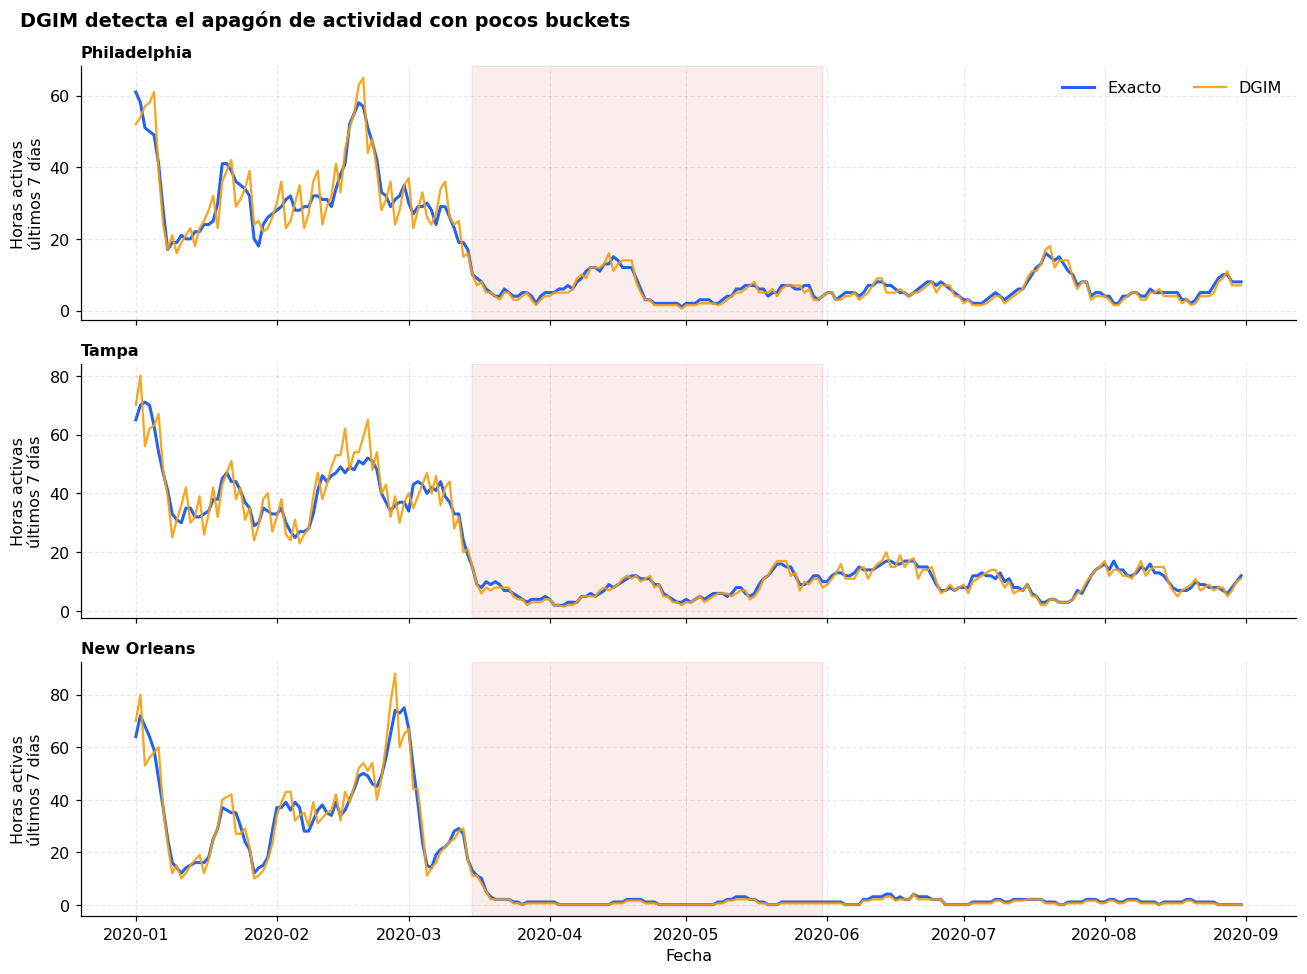

In [7]:
dgim_rows=[]; dgim_summary=[]
full_hours=pd.date_range('2019-01-01','2021-12-31 23:00:00',freq='h')
for metro in ['Philadelphia','Tampa','New Orleans']:
    s=(hourly_dgim.query('metro==@metro').set_index('hora').eventos.reindex(full_hours,fill_value=0).astype(int))
    how=s.index.dayofweek*24+s.index.hour
    base=s[s.index.year==2019]; base_how=base.index.dayofweek*24+base.index.hour
    thresholds=base.groupby(base_how).quantile(.75)
    bits=(s.to_numpy()>thresholds.reindex(how).to_numpy()).astype(np.int8)
    ev=st.evaluate_dgim(bits,window_size=168); ev['hora']=full_hours; ev['metro']=metro; ev['bit']=bits
    dgim_rows.append(ev)
    valid=ev[ev.exact>0]
    dgim_summary.append(dict(metro=metro,activa_2019=bits[s.index.year==2019].mean(),mae=ev.abs_error.mean(),p95_rel=np.percentile(valid.relative_error,95),max_rel=valid.relative_error.max(),max_buckets=ev.buckets.max()))
dgim_eval=pd.concat(dgim_rows,ignore_index=True); dgim_summary=pd.DataFrame(dgim_summary)
print(dgim_summary.to_string(index=False,formatters={'activa_2019':'{:.1%}'.format,'mae':'{:.2f}'.format,'p95_rel':'{:.1%}'.format,'max_rel':'{:.1%}'.format}))

fig,axes=plt.subplots(3,1,figsize=(12,9),sharex=True)
for ax,metro in zip(axes,['Philadelphia','Tampa','New Orleans']):
    q=dgim_eval.query('metro==@metro and hora>="2020-01-01" and hora<"2020-09-01"').set_index('hora').resample('D').last()
    ax.plot(q.index,q.exact,color=P['azul'],lw=2,label='Exacto')
    ax.plot(q.index,q.estimate,color=P['naranja'],lw=1.5,alpha=.9,label='DGIM')
    ax.axvspan(pd.Timestamp('2020-03-15'),pd.Timestamp('2020-05-31'),color=P['rojo'],alpha=.08)
    ax.set_ylabel('Horas activas\núltimos 7 días'); ax.set_title(metro,loc='left',fontsize=10.5)
axes[0].legend(ncol=2,loc='upper right'); axes[-1].set_xlabel('Fecha')
fig.suptitle('DGIM detecta el apagón de actividad con pocos buckets',fontweight='bold',x=.02,ha='left')
print(viz.guardar(fig,'parte5_dgim_actividad')); plt.show()


DGIM conserva solo **10–11 buckets** para una ventana de 168 horas. El MAE semanal queda entre 1.76 y 2.15 horas; el p95 relativo es 33–50% y el máximo respeta exactamente la cota de 50%. Aun con esa aproximación, reproduce el cambio de régimen de marzo de 2020: Philadelphia y Tampa caen a pocas horas activas y New Orleans prácticamente a cero. DGIM no reconstruye cada bit; conserva suficiente estructura para detectar el apagón con memoria logarítmica.

## Paso 6 — COVID-19: actividad física y opinión no caen igual

Unimos eventos diarios con casos NYT por los `county_fips` de cada mercado. Agregamos por semana y normalizamos cada señal por la mediana semanal de 2019. Check-ins aproximan presencia física; reviews pueden escribirse después y reaccionar distinto.


Índice medio durante 15-mar→31-may 2020 (2019=100):
       metro checkin_index review_index
 New Orleans          14.8         24.7
Philadelphia          15.9         33.2
       Tampa          33.1         39.8


docs/figs/parte5_covid_actividad.png


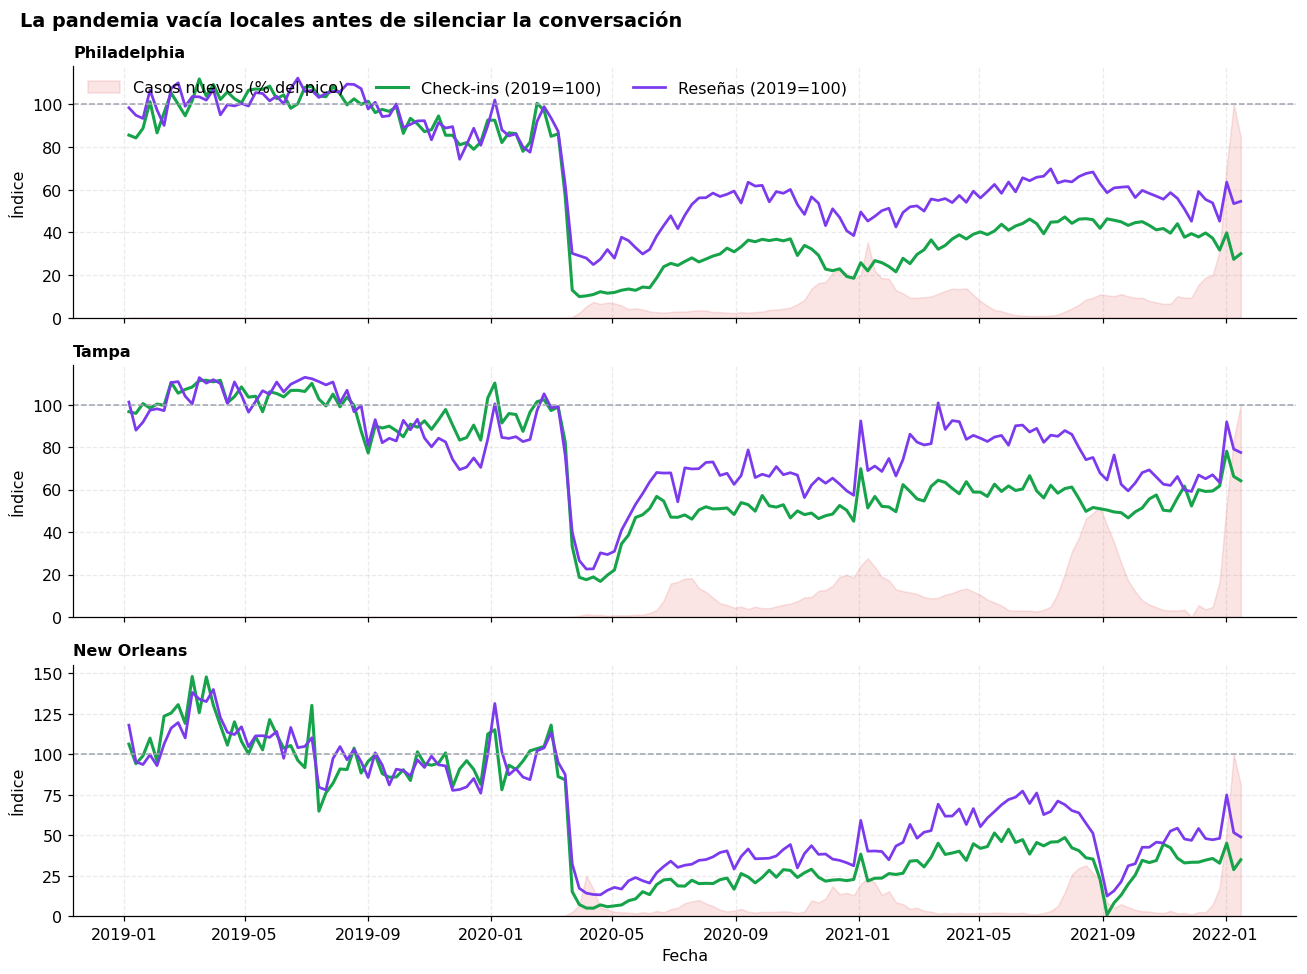

In [8]:
# Actividad semanal completa por mercado/tipo
activity_rows=[]
date_index=pd.date_range('2019-01-01','2022-01-19',freq='D')
for metro in ['Philadelphia','Tampa','New Orleans']:
    pivot=(daily_universe.query('metro==@metro').pivot_table(index='fecha',columns='tipo',values='eventos',aggfunc='sum',fill_value=0))
    pivot.index=pd.to_datetime(pivot.index); pivot=pivot.reindex(date_index,fill_value=0)
    weekly=pivot.resample('W-SUN').sum(); weekly['metro']=metro; activity_rows.append(weekly.reset_index(names='fecha'))
weekly_activity=pd.concat(activity_rows,ignore_index=True)
for col in ['checkin','review']:
    baseline=weekly_activity[weekly_activity.fecha.dt.year==2019].groupby('metro')[col].median()
    weekly_activity[f'{col}_index']=100*weekly_activity[col]/weekly_activity.metro.map(baseline)

# Casos nuevos semanales en counties cubiertos por negocios del universo
covid=pd.concat([pd.read_csv(EXTERNAL/f'covid_nyt_{year}.csv') for year in [2020,2021,2022]],ignore_index=True)
covid['date']=pd.to_datetime(covid.date); covid['fips']=pd.to_numeric(covid.fips,errors='coerce').astype('Int64')
covid=covid.sort_values(['fips','date']); covid['new_cases']=covid.groupby('fips').cases.diff().fillna(0).clip(lower=0)
county_map=pd.read_parquet(GOLD/'negocios_universo.parquet',columns=['metro','county_fips']).dropna().drop_duplicates()
county_map['fips']=pd.to_numeric(county_map.county_fips,errors='coerce').astype('Int64')
covid_m=(covid.merge(county_map[['metro','fips']],on='fips').groupby(['metro','date'],as_index=False).new_cases.sum())
covid_w=(covid_m.set_index('date').groupby('metro').new_cases.resample('W-SUN').sum().reset_index())
weekly_covid=weekly_activity.merge(covid_w,left_on=['metro','fecha'],right_on=['metro','date'],how='left').drop(columns='date')
weekly_covid['new_cases']=weekly_covid.new_cases.fillna(0)
weekly_covid['covid_peak_index']=100*weekly_covid.new_cases/weekly_covid.groupby('metro').new_cases.transform('max').replace(0,np.nan)
lock=weekly_covid[weekly_covid.fecha.between('2020-03-15','2020-05-31')]
lock_summary=lock.groupby('metro')[['checkin_index','review_index']].mean().reset_index()
print('Índice medio durante 15-mar→31-may 2020 (2019=100):')
print(lock_summary.to_string(index=False,formatters={'checkin_index':'{:.1f}'.format,'review_index':'{:.1f}'.format}))

fig,axes=plt.subplots(3,1,figsize=(12,9),sharex=True)
for ax,metro in zip(axes,['Philadelphia','Tampa','New Orleans']):
    q=weekly_covid.query('metro==@metro and fecha<="2022-01-16"')
    ax.fill_between(q.fecha,0,q.covid_peak_index,color=P['rojo'],alpha=.12,label='Casos nuevos (% del pico)')
    ax.plot(q.fecha,q.checkin_index,color=P['verde'],lw=2,label='Check-ins (2019=100)')
    ax.plot(q.fecha,q.review_index,color=P['morado'],lw=1.8,label='Reseñas (2019=100)')
    ax.axhline(100,color=P['gris'],ls='--',lw=1); ax.set_ylabel('Índice'); ax.set_title(metro,loc='left',fontsize=10.5); ax.set_ylim(bottom=0)
axes[0].legend(ncol=3,loc='upper left'); axes[-1].set_xlabel('Fecha')
fig.suptitle('La pandemia vacía locales antes de silenciar la conversación',fontweight='bold',x=.02,ha='left')
print(viz.guardar(fig,'parte5_covid_actividad')); plt.show()


Durante 15-mar→31-may de 2020, los check-ins caen a **15.9%** del nivel 2019 en Philadelphia, **14.8%** en New Orleans y **33.1%** en Tampa; las reseñas quedan más altas (33.2%, 24.7% y 39.8%). La presencia física se apaga antes y más fuerte que la conversación. COVID evita atribuir a un restaurante un shock de ciudad y muestra que “actividad” no es una sola variable. La figura termina en la última semana completa (16-ene-2022) para no dibujar como caída el corte del dataset.

## Paso 7 — Mardi Gras como experimento natural

Para cada Mardi Gras de 2010–2021 comparamos check-ins de `día relativo -14…+14` contra seis días del mismo weekday a ±2/3/4 semanas. Philadelphia y Tampa actúan como placebo sobre las mismas fechas. El índice elimina crecimiento anual y patrón semanal.


Índice de check-ins en Mardi Gras (weekday comparable=100):
       metro mediana q25 q75
 New Orleans     187 165 203
Philadelphia      97  93 101
       Tampa     101  94 109


docs/figs/parte5_mardi_gras.png


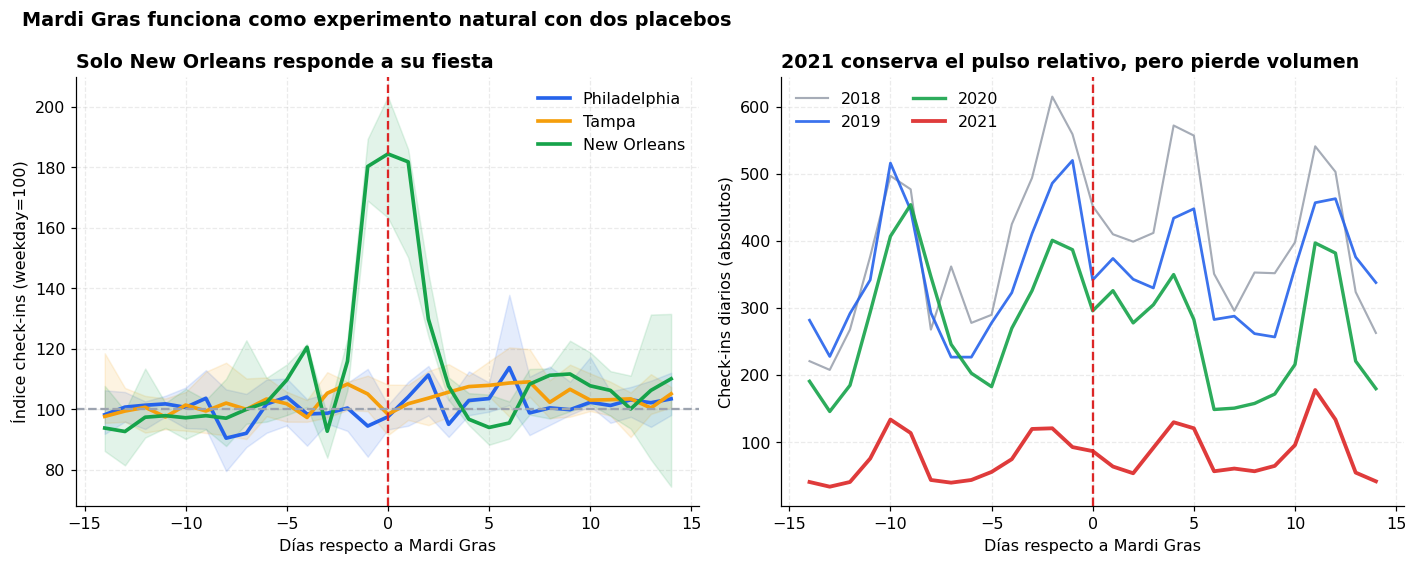

In [9]:
holidays=pd.read_csv(EXTERNAL/'feriados.csv'); holidays['fecha']=pd.to_datetime(holidays.fecha)
mardi_dates=holidays.query('feriado=="Mardi Gras" and fecha>="2010-01-01" and fecha<="2021-12-31"').fecha.tolist()
checkins=daily_universe.query('tipo=="checkin"').copy(); checkins['fecha']=pd.to_datetime(checkins.fecha)
lookup={(r.metro,r.fecha):r.eventos for r in checkins.itertuples()}
mardi_rows=[]
for event_date in mardi_dates:
    for metro in ['Philadelphia','Tampa','New Orleans']:
        for rel in range(-14,15):
            target=event_date+pd.Timedelta(days=rel); value=lookup.get((metro,target),0)
            matched=[lookup.get((metro,target+pd.Timedelta(days=7*k)),0) for k in [-4,-3,-2,2,3,4]]
            baseline=float(np.median(matched))
            if baseline>0: mardi_rows.append(dict(year=event_date.year,evento=event_date,metro=metro,dia_rel=rel,checkins=value,baseline=baseline,index=100*value/baseline))
mardi=pd.DataFrame(mardi_rows)
pre=mardi.query('year<=2020').groupby(['metro','dia_rel']).agg(mediana=('index','median'),q25=('index',lambda x:np.percentile(x,25)),q75=('index',lambda x:np.percentile(x,75))).reset_index()
event_summary=mardi.query('dia_rel==0').groupby('metro').agg(mediana=('index','median'),q25=('index',lambda x:np.percentile(x,25)),q75=('index',lambda x:np.percentile(x,75))).reset_index()
print('Índice de check-ins en Mardi Gras (weekday comparable=100):')
print(event_summary.to_string(index=False,formatters={'mediana':'{:.0f}'.format,'q25':'{:.0f}'.format,'q75':'{:.0f}'.format}))

fig,axes=plt.subplots(1,2,figsize=(13,5.2))
ax=axes[0]
for metro in ['Philadelphia','Tampa','New Orleans']:
    q=pre.query('metro==@metro'); color=viz.MERCADOS[metro]
    ax.plot(q.dia_rel,q.mediana,color=color,lw=2.4,label=metro); ax.fill_between(q.dia_rel,q.q25,q.q75,color=color,alpha=.12)
ax.axvline(0,color=P['rojo'],ls='--'); ax.axhline(100,color=P['gris'],ls='--'); ax.set(xlabel='Días respecto a Mardi Gras',ylabel='Índice check-ins (weekday=100)',title='Solo New Orleans responde a su fiesta'); ax.legend()
ax=axes[1]
for year,color,lw in [(2018,P['gris'],1.4),(2019,P['azul'],1.8),(2020,P['verde'],2.2),(2021,P['rojo'],2.5)]:
    q=mardi.query('metro=="New Orleans" and year==@year'); ax.plot(q.dia_rel,q.checkins,label=str(year),color=color,lw=lw,alpha=.9)
ax.axvline(0,color=P['rojo'],ls='--'); ax.set(xlabel='Días respecto a Mardi Gras',ylabel='Check-ins diarios (absolutos)',title='2021 conserva el pulso relativo, pero pierde volumen'); ax.legend(ncol=2)
fig.suptitle('Mardi Gras funciona como experimento natural con dos placebos',fontweight='bold',x=.02,ha='left')
print(viz.guardar(fig,'parte5_mardi_gras')); plt.show()


El día de Mardi Gras alcanza un índice mediano de **187** en New Orleans frente a 97 en Philadelphia y 101 en Tampa: los placebos descartan una estacionalidad nacional. En 2021 el pico relativo sigue visible porque su baseline también está deprimido, pero el volumen absoluto cae a **87 check-ins vs 296 en 2020** (−71%). El doble panel evita una trampa: un índice alto no implica recuperación del nivel de actividad.

## Paso 8 — Persistencia

Guardamos resultados pequeños y reutilizables. El stream crudo ya existe en Gold; no duplicamos 20M filas. Las métricas de tiempo, memoria y error pasan directamente a Parte VII.


In [10]:
windows.to_parquet(GOLD/'ventanas_stream.parquet',index=False)
cms_metrics.to_parquet(GOLD/'metricas_cms.parquet',index=False)
top_rest[['business_id','name','metro','frecuencia_exacta','frecuencia_cms','error']].to_parquet(GOLD/'frecuencias_cms_top.parquet',index=False)
dgim_eval.to_parquet(GOLD/'evaluacion_dgim.parquet',index=False)
weekly_covid.to_parquet(GOLD/'actividad_covid_semanal.parquet',index=False)
mardi.to_parquet(GOLD/'impacto_mardi_gras.parquet',index=False)
print('Guardadas 6 tablas gold y 6 figuras de Parte V')


Guardadas 6 tablas gold y 6 figuras de Parte V


## Resumen del notebook

1. Procesamos el stream completo mediante ventanas exactas 1h/4h/24h.
2. CMS recorrió 20.35M eventos, contrastó error empírico con `εN` y preservó heavy hitters.
3. DGIM aportó la técnica adicional: seguimiento aproximado de horas activas con memoria logarítmica.
4. COVID separó presencia física de conversación; Mardi Gras aportó experimento natural y placebos.
5. Persistimos seis tablas y seis figuras para informe y Parte VII.

**Parte V completa:** ventanas ✓ · CMS+cota ✓ · comparación exacta ✓ · DGIM ✓ · COVID ✓ · feriados/Mardi Gras ✓.
